<a href="https://colab.research.google.com/github/gusti-amber/udemy_pytorch/blob/main/lecture/lec6_train_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 画像分類Webアプリで使用するモデルの訓練

# 1. データの前処理
CIFAR-10を読み込み、データ拡張とDataLoaderの設定を行う。

In [1]:
from torchvision.datasets import CIFAR10
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# 前処理パイプラインの設定
affine = transforms.RandomAffine([-15, 15], scale=(0.8, 1.2))  # 回転とリサイズ
flip = transforms.RandomHorizontalFlip(p=0.5)  # 左右反転
normalize = transforms.Normalize((0.0, 0.0, 0.0), (1.0, 1.0, 1.0))  # 正規化
to_tensor = transforms.ToTensor()

transform_train = transforms.Compose([affine, flip, to_tensor, normalize])
transform_test = transforms.Compose([to_tensor, normalize])

# CIFAR-10の読み込み
cifar10_train = CIFAR10("./data", train=True, download=True, transform=transform_train)
cifar10_test = CIFAR10("./data", train=False, download=True, transform=transform_test)

# DataLoaderの設定
batch_size = 64
train_loader = DataLoader(cifar10_train, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(cifar10_test, batch_size=len(cifar10_test), shuffle=False)

100%|██████████| 170M/170M [00:03<00:00, 43.3MB/s]


# 2. モデルの構築
CNNモデルを構築する。

In [2]:
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)  # 畳み込み層:(入力チャンネル数, フィルタ数、フィルタサイズ)
        self.pool = nn.MaxPool2d(2, 2)  # プーリング層:（領域のサイズ, ストライド）
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16*5*5, 256)  # 全結合層
        self.dropout = nn.Dropout(p=0.5)  # ドロップアウト:(確率p:0.5)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16*5*5)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

net = Net()
net.cuda()  # GPU対応
print(net)

Net(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=256, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)


# 3. モデルの学習

In [3]:
from torch import optim

# 損失関数: 交差エントロピー誤差関数
loss_fnc = nn.CrossEntropyLoss()

# 最適化アルゴリズム: Adam
optimizer = optim.Adam(net.parameters())

# 損失ログ
record_loss_train = []
record_loss_test = []

# 学習
x_test, t_test = next(iter(test_loader))
x_test, t_test = x_test.cuda(), t_test.cuda()
for i in range(20):  # 20エポック
    # 訓練
    net.train()
    loss_train = 0
    for j, (x, t) in enumerate(train_loader):  # ミニバッチ（x, t）を取り出す
        x, t = x.cuda(), t.cuda()  # GPU対応

        y = net(x)
        loss = loss_fnc(y, t)
        loss_train += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    loss_train /= j+1
    record_loss_train.append(loss_train)

    # 評価
    net.eval()
    y_test = net(x_test)
    loss_test = loss_fnc(y_test, t_test).item()
    record_loss_test.append(loss_test)

    if i%1 == 0:
        print("Epoch:", i, "Loss_Train:", loss_train, "Loss_Test:", loss_test)

Epoch: 0 Loss_Train: 1.8012778624854124 Loss_Test: 1.5971932411193848
Epoch: 1 Loss_Train: 1.6081518402794743 Loss_Test: 1.467743158340454
Epoch: 2 Loss_Train: 1.535464879496933 Loss_Test: 1.4188315868377686
Epoch: 3 Loss_Train: 1.4928890966698336 Loss_Test: 1.361487865447998
Epoch: 4 Loss_Train: 1.4614708396175025 Loss_Test: 1.3150502443313599
Epoch: 5 Loss_Train: 1.4235273825238124 Loss_Test: 1.295438289642334
Epoch: 6 Loss_Train: 1.3988743805519455 Loss_Test: 1.266817331314087
Epoch: 7 Loss_Train: 1.383497957454618 Loss_Test: 1.2653982639312744
Epoch: 8 Loss_Train: 1.3584951738567304 Loss_Test: 1.2279255390167236
Epoch: 9 Loss_Train: 1.3486703707434027 Loss_Test: 1.2241452932357788
Epoch: 10 Loss_Train: 1.3349296280642604 Loss_Test: 1.261240839958191
Epoch: 11 Loss_Train: 1.326702599863872 Loss_Test: 1.2123138904571533
Epoch: 12 Loss_Train: 1.3143197947450915 Loss_Test: 1.1962344646453857
Epoch: 13 Loss_Train: 1.3075785668914581 Loss_Test: 1.1810396909713745
Epoch: 14 Loss_Train: 1.

# 4. 訓練データとテストデータの誤差の推移

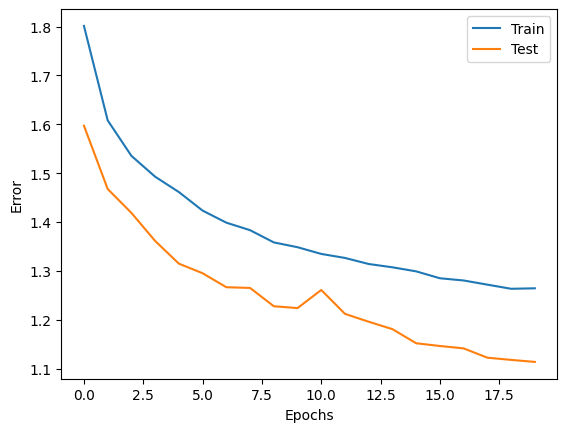

In [4]:
import matplotlib.pyplot as plt

plt.plot(range(len(record_loss_train)), record_loss_train, label="Train")
plt.plot(range(len(record_loss_test)), record_loss_test, label="Test")
plt.legend()

plt.xlabel("Epochs")
plt.ylabel("Error")
plt.show()

# 5. モデルの評価

In [5]:
correct = 0
total = 0
net.eval()  # 評価モード
for i, (x, t) in enumerate(test_loader):
    x, t = x.cuda(), t.cuda()  # GPU対応
    y = net(x)
    correct += (y.argmax(1) == t).sum().item()
    total += len(x)
print("正解率:", str(correct/total*100) + "%")

正解率: 60.6%


# 6. モデルの保存
訓練済みモデルのパラメータを保存する。

state_dict()によりモデルの各パラメータを取得する。

In [6]:
import torch

for key in net.state_dict():
  print(key, ":", net.state_dict()[key].size())
print(net.state_dict()["conv1.weight"][0]) # パラメータ表示

torch.save(net.state_dict(), "model_cnn.pth")

conv1.weight : torch.Size([6, 3, 5, 5])
conv1.bias : torch.Size([6])
conv2.weight : torch.Size([16, 6, 5, 5])
conv2.bias : torch.Size([16])
fc1.weight : torch.Size([256, 400])
fc1.bias : torch.Size([256])
fc2.weight : torch.Size([10, 256])
fc2.bias : torch.Size([10])
tensor([[[ 0.0098,  0.0487,  0.1126,  0.0159, -0.0456],
         [ 0.2326,  0.0954,  0.0634,  0.1625,  0.0853],
         [ 0.1771,  0.0536,  0.0566,  0.1380, -0.0089],
         [-0.1259, -0.3057, -0.2559, -0.1746, -0.0397],
         [-0.0417, -0.0327, -0.0077, -0.1573,  0.0086]],

        [[ 0.0078, -0.1297,  0.0149, -0.0056,  0.0638],
         [ 0.1341,  0.1963,  0.1296, -0.0035, -0.0962],
         [-0.0578,  0.0364,  0.1656,  0.0930, -0.0432],
         [-0.2601, -0.2557, -0.2493, -0.0118, -0.0696],
         [-0.0505, -0.1683, -0.0017, -0.1337,  0.1003]],

        [[-0.1696, -0.0012, -0.0993, -0.1246, -0.0495],
         [ 0.1148,  0.1226,  0.0801,  0.0187,  0.0413],
         [ 0.0562,  0.1138,  0.0962, -0.0958, -0.0912],


# 7. モデルの読み込み
保存したパラメータを読み込みモデルに設定する。
torch.load()でmap_locationにCPUを指定することで、GPUで訓練したモデルをCPUで使用することできる。

In [7]:
# モデルの読み込み
net_loaded = Net()
net_loaded.load_state_dict(torch.load("model_cnn.pth",
                                      map_location=torch.device("cpu")))  #CPU対応
net_loaded.eval()  # 評価モードに設定

# state_dict()の表示
for key in net_loaded.state_dict():
    print(key, ": ", net.state_dict()[key].size())
print(net_loaded.state_dict()["conv1.weight"][0])  # 　パラメータの一部を表示

conv1.weight :  torch.Size([6, 3, 5, 5])
conv1.bias :  torch.Size([6])
conv2.weight :  torch.Size([16, 6, 5, 5])
conv2.bias :  torch.Size([16])
fc1.weight :  torch.Size([256, 400])
fc1.bias :  torch.Size([256])
fc2.weight :  torch.Size([10, 256])
fc2.bias :  torch.Size([10])
tensor([[[ 0.0098,  0.0487,  0.1126,  0.0159, -0.0456],
         [ 0.2326,  0.0954,  0.0634,  0.1625,  0.0853],
         [ 0.1771,  0.0536,  0.0566,  0.1380, -0.0089],
         [-0.1259, -0.3057, -0.2559, -0.1746, -0.0397],
         [-0.0417, -0.0327, -0.0077, -0.1573,  0.0086]],

        [[ 0.0078, -0.1297,  0.0149, -0.0056,  0.0638],
         [ 0.1341,  0.1963,  0.1296, -0.0035, -0.0962],
         [-0.0578,  0.0364,  0.1656,  0.0930, -0.0432],
         [-0.2601, -0.2557, -0.2493, -0.0118, -0.0696],
         [-0.0505, -0.1683, -0.0017, -0.1337,  0.1003]],

        [[-0.1696, -0.0012, -0.0993, -0.1246, -0.0495],
         [ 0.1148,  0.1226,  0.0801,  0.0187,  0.0413],
         [ 0.0562,  0.1138,  0.0962, -0.0958, -0